# Historical Volatility Forecasting

Now since I want to build technical forecasting methods, I begin by developing a simple volatility forecasting model which uses historical volatility averages. I would like evaluate its ability to predict future volatility. Find its flaws and use it as a baseline for other models which are more complex than this.

# Introduction

Historical Volatility Forecasting assumes that future volatility will resemble recent historical volatility. This does make sense in the beginning but probably fails to model crashes and hence quite unreliable. 

Since it is so simple, I assume it will be easy to implement and so I try to build it.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

plt.style.use("ggplot")

START = "2005-01-01"

In [ ]:
# copied from notebook 2

In [2]:
spy = yf.download(
    "SPY",
    start=START,
    auto_adjust=True
)

spy["returns"] = np.log(
    spy["Close"] /
    spy["Close"].shift(1)
)

spy["rv_20"] = (
    spy["returns"]
    .rolling(20)
    .std()
    * np.sqrt(252)
)

spy["target_20d"] = (
    spy["rv_20"]
    .shift(-20)
)

spy = spy.dropna()

[*********************100%***********************]  1 of 1 completed


# Experiment 1: Historical Volatility Forecast

If volatility is running high, we assume volatility will remain high. If volatility is running low, we assume volatility will remain low.

Based on this concept, the historical volatility forecasting model uses averages of past volatility observations to estimate future volatility.

In [3]:
spy["hv_forecast"] = (
    spy["rv_20"]
    .rolling(20)
    .mean()
)

spy[
    [
        "hv_forecast",
        "target_20d"
    ]
].tail()

Price,hv_forecast,target_20d
Ticker,,
Date,,
2026-05-08,0.152664,0.129134
2026-05-11,0.147974,0.129300
2026-05-12,0.143051,0.140862
2026-05-13,0.138015,0.152883
2026-05-14,0.133536,0.151376


## Comments

The deviation shows that this clearly is not the best fit

# Experiment 2: Comparing Forecasts Against Realized Volatility

A forecasting model needs to capture broad movements in volatility. Ofcourse prediction cannot be perfect but even tracking future volatility in the same direction a good step in the right direction. Here we do exactly that

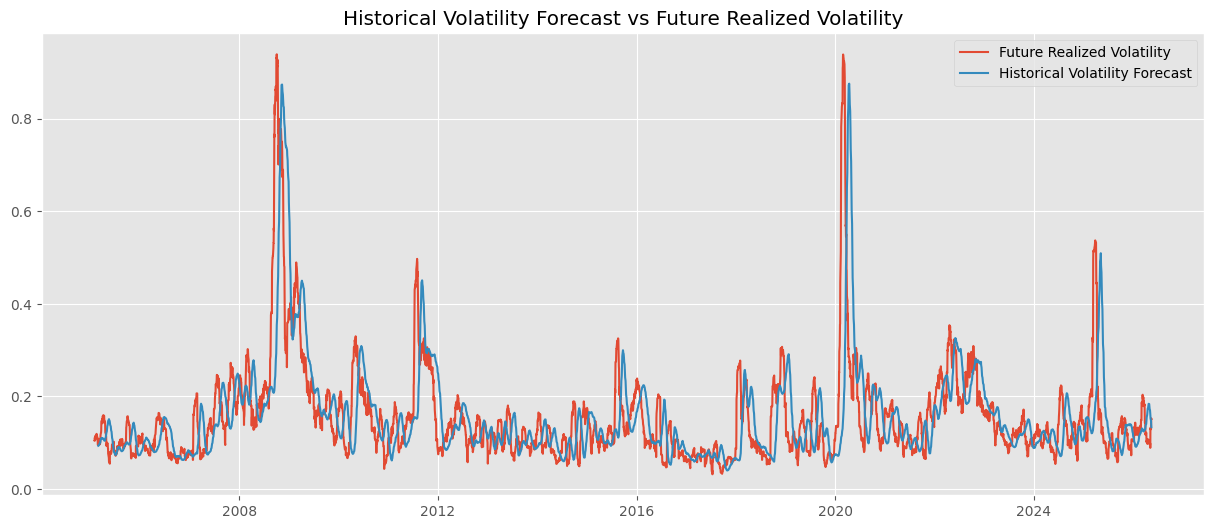

In [4]:
plt.figure(figsize=(15,6))

plt.plot(
    spy.index,
    spy["target_20d"],
    label="Future Realized Volatility"
)

plt.plot(
    spy.index,
    spy["hv_forecast"],
    label="Historical Volatility Forecast"
)

plt.legend()

plt.title(
    "Historical Volatility Forecast vs Future Realized Volatility"
)

plt.show()

## Comments 

It captures broad volatility trends. However, the model is slow and less sharp. Honestly, it looks like it lags a bit than the realised volatility. This is because it is based on averages of the past and so rapid fluctuations make it difficult to capture the correct movement. 


# Experiment 3: Error Analysis

Let us now try to check the quality of prediction by comparing errors. If there is persistent error, we will need to modify some things

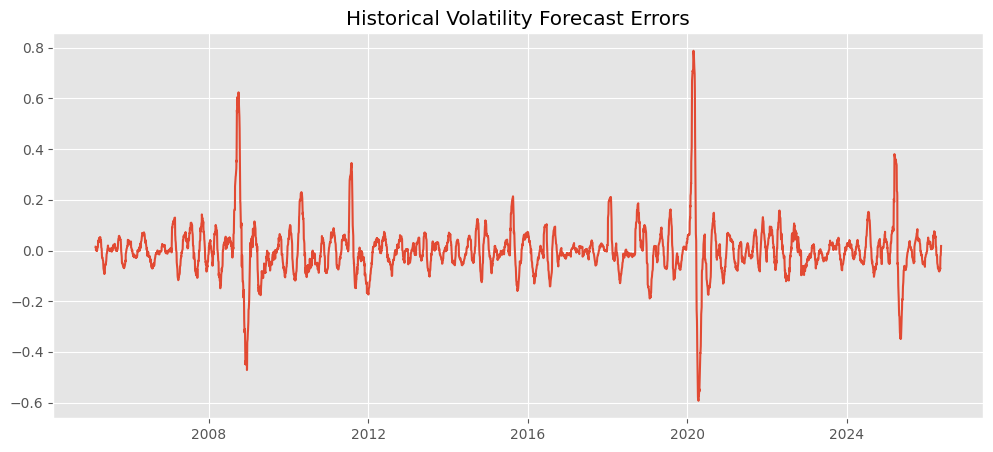

In [5]:
spy["error"] = (
    spy["target_20d"]
    - spy["hv_forecast"]
)

plt.figure(figsize=(12,5))

plt.plot(
    spy.index,
    spy["error"]
)

plt.title(
    "Historical Volatility Forecast Errors"
)

plt.show()

## Comments

As expected, the error is high during huge jumps or falls. When the changes are rapid, taking the average of the past doesn't help. This essentially proves that we need somethng that adapts to these crashes.

# Experiment 4: Error Distribution

Let's try to see the distribution of the errors above so we can use our knowledge of probability to make helpful decisions

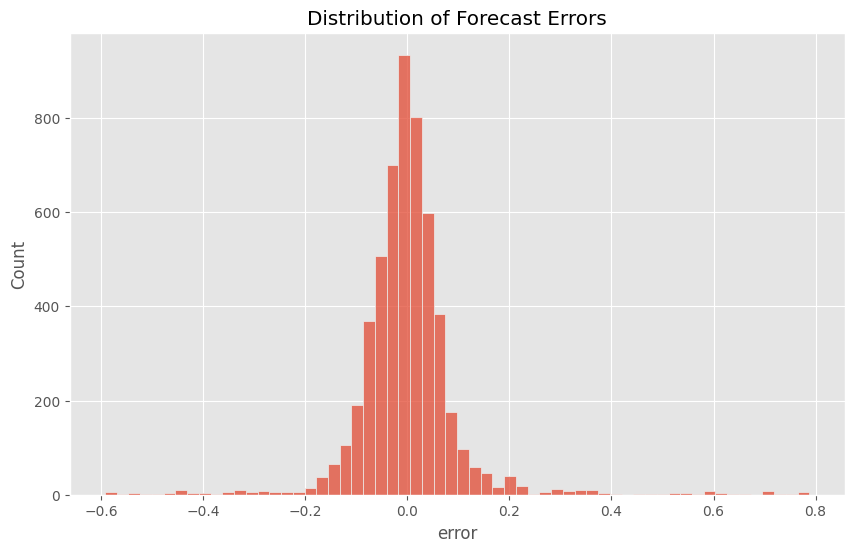

In [6]:
plt.figure(figsize=(10,6))

sns.histplot(
    spy["error"].dropna(),
    bins=60
)

plt.title(
    "Distribution of Forecast Errors"
)

plt.show()

## Comments

I mean the distribution doesnt look skewed to one side. It tend doesnt over or underestimate. It does both equally. A wide plot just shows that precision is low. Big errors are uncommon but never impossible.

# Experiment 5: Forecast Accuracy Metrics

Instead of the plot, looking at MAE and RMSE would be more helpful. This way we can see if the average error is concernning

In [10]:
evaluation_df = spy[
    [
        "target_20d",
        "hv_forecast"
    ]
].dropna()

rmse = np.sqrt(
    mean_squared_error(
        evaluation_df["target_20d"],
        evaluation_df["hv_forecast"]
    )
)

mae = mean_absolute_error(
    evaluation_df["target_20d"],
    evaluation_df["hv_forecast"]
)
    
metrics = pd.DataFrame(
    {
        "Metric": ["RMSE", "MAE"],
        "Value": [rmse, mae]
    }
)

metrics

,Metric,Value
0,RMSE,0.102388
1,MAE,0.059998


## Comments

Now we can use these values are our base performance level. We would love it if future models improve these values.

# Experiment 6: Historical Volatility During Market Stress

This model would be the best one if market was stable. But the most important situation in markets in periods of high risk. This is the whole reason we build forecasting models in the first place. So usefulness during masket stress is the most important aspect of a forecasting model. Let's see how our HVF model performs


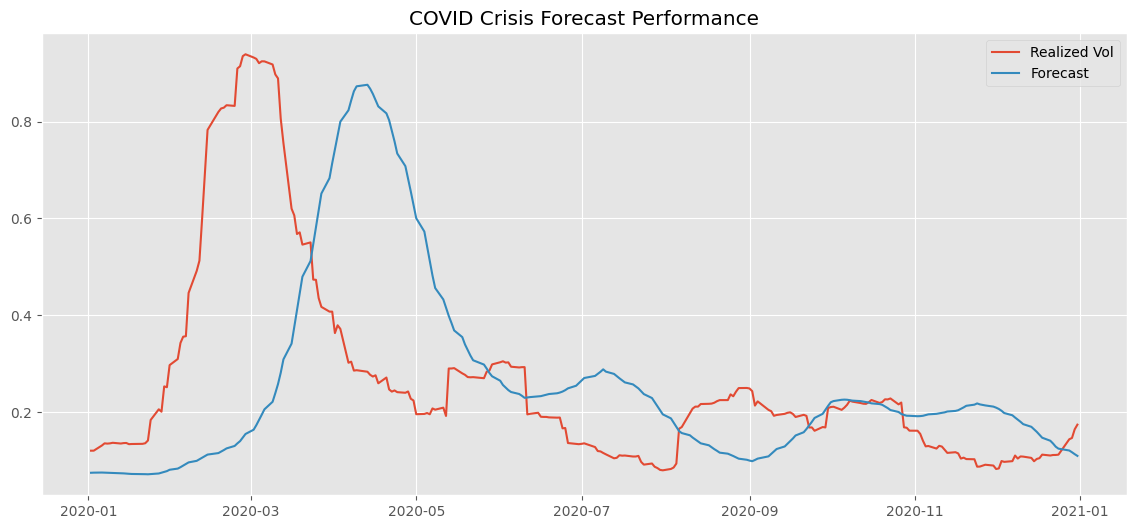

In [11]:
covid = spy.loc[
    "2020-01-01":"2021-01-01"
]

plt.figure(figsize=(14,6))

plt.plot(
    covid.index,
    covid["target_20d"],
    label="Realized Vol"
)

plt.plot(
    covid.index,
    covid["hv_forecast"],
    label="Forecast"
)

plt.legend()

plt.title(
    "COVID Crisis Forecast Performance"
)

plt.show()

## Comments

Our model struggles. Ofcourse there is the characteristic lag but at certain times it gives the exact opposite direction. This justifies the need to continue this project and build better forecasting models.

# Experiment 7: Forecast Window Sensitivity

One would assume that short windows respond rapidly to new information and long windows provide smoother estimates. There is therefore a trade-off between responsiveness and stability.
Let's try to visualise that simply.

In [12]:
for w in [10,20,60]:

    spy[f"hv_{w}"] = (
        spy["rv_20"]
        .rolling(w)
        .mean()
    )

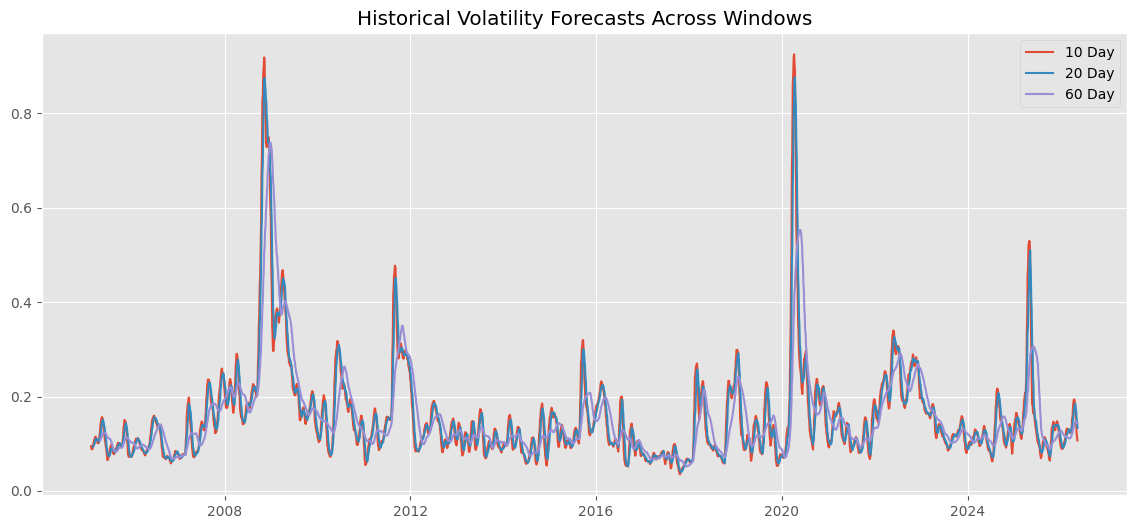

In [13]:
plt.figure(figsize=(14,6))

plt.plot(
    spy.index,
    spy["hv_10"],
    label="10 Day"
)

plt.plot(
    spy.index,
    spy["hv_20"],
    label="20 Day"
)

plt.plot(
    spy.index,
    spy["hv_60"],
    label="60 Day"
)

plt.legend()

plt.title(
    "Historical Volatility Forecasts Across Windows"
)

plt.show()

## Interpretation

Short window forecasts react more quickly but exhibit greater noise. Long window forecasts are smoother but slower and less sharp. Best choice of length of window would chnage depending on situations. This is another aspect we could add in our model.

# Conclusions

Historical volatility forecasting acts as benchmark for volatility prediction. I learnt that HVF accuracy deteriorates during crisis. There is a characteristic lag. Performance depends on time window.

There is scope for lots of improvement, we shall work on this on subsequent notebooks and keep coming back to the benchmark set here to compare improvement. 